# Isolation Forest

## Import Library

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

## Load Dataset

In [17]:
df = pd.read_csv("../Datasheet/OBD-Anomaly-Detection/dataset/preprocessing.csv")

print(df.shape)

df.head()

(1029, 9)


,lat,lng,MAF,Speed,GPH,LPH,KPL,CO2 Emissions,Anomaly
0,0.478759,2.143419,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
1,0.474486,2.079248,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
2,0.480184,2.014739,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
3,0.480997,1.977785,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
4,0.504587,1.543742,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0


## Memisahkan Feature dan Label

In [18]:
X = df.drop(columns=["Anomaly"])
y = df["Anomaly"]

## Melatih Model Isolation Forest

In [19]:
isolation = IsolationForest(
    contamination=0.05,
    random_state=42
)

isolation.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


## Prediksi Anomali

In [20]:
prediction = isolation.predict(X)

prediction = np.where(prediction==-1,1,0)

## Membuat Prediction

In [21]:
prediction = isolation.predict(X)

prediction = np.where(prediction == -1, 1, 0)

df["Prediction"] = prediction

df.head()

,lat,lng,MAF,Speed,GPH,LPH,KPL,CO2 Emissions,Anomaly,Prediction
0,0.478759,2.143419,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0,0
1,0.474486,2.079248,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0,0
2,0.480184,2.014739,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0,0
3,0.480997,1.977785,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0,0
4,0.504587,1.543742,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0,0


## Menyimpan hasil

In [22]:
df.to_csv(
    "../Datasheet/OBD-Anomaly-Detection/dataset/isolation_result.csv",
    index=False
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.


## Menambahkan Hasil Prediksi

In [23]:
df["Prediction"] = prediction

## Tambahkan kolom Anomaly

In [24]:
df["Anomaly"] = 0

df.loc[df["Speed"] > 80,"Anomaly"] = 1

## Visualisasi Hasil Prediksi

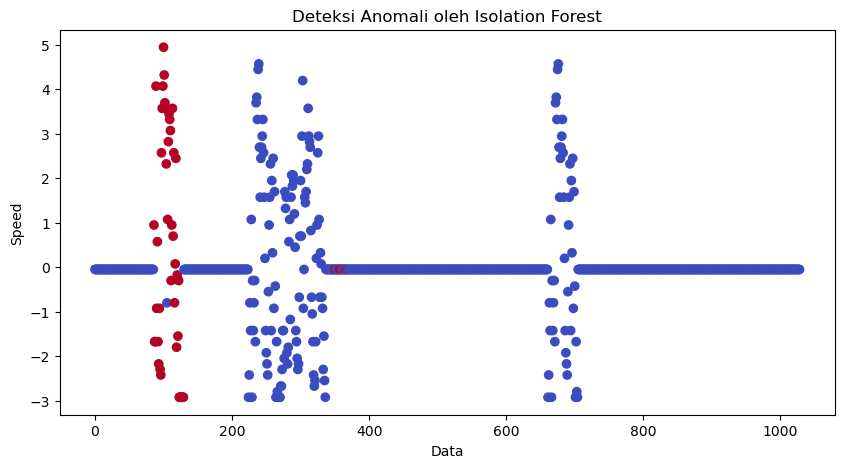

In [25]:
plt.figure(figsize=(10,5))

plt.scatter(df.index,
            df["Speed"],
            c=df["Prediction"],
            cmap="coolwarm")

plt.xlabel("Data")
plt.ylabel("Speed")
plt.title("Deteksi Anomali oleh Isolation Forest")

plt.show()

## Confusion Matrix

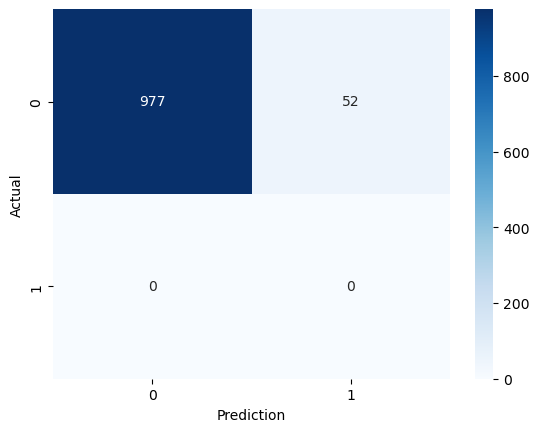

In [26]:
cm = confusion_matrix(
    df["Anomaly"],
    df["Prediction"]
)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues")

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

## Menghitung Metric

In [27]:
accuracy = accuracy_score(df["Anomaly"], df["Prediction"])
precision = precision_score(df["Anomaly"], df["Prediction"])
recall = recall_score(df["Anomaly"], df["Prediction"])
f1 = f1_score(df["Anomaly"], df["Prediction"])

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9494655004859086
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Classification Report

In [28]:
print(classification_report(
    df["Anomaly"],
    df["Prediction"]
))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1029
           1       0.00      0.00      0.00         0

    accuracy                           0.95      1029
   macro avg       0.50      0.47      0.49      1029
weighted avg       1.00      0.95      0.97      1029



c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Menyimpan Model

In [29]:
from sklearn.ensemble import IsolationForest
import joblib

# 1. Kita buat dan latih ulang modelnya (kita beri nama variabel 'iso')
# Asumsinya data latih kamu bernama 'X_train' atau 'df', sesuaikan jika namanya berbeda
iso = IsolationForest(n_estimators=100, random_state=42)
iso.fit(df) # Ganti 'df' dengan nama variabel datamu yang sudah bersih

# 2. Simpan modelnya dengan nama yang benar
joblib.dump(iso, "../model/isolationforest.pkl")
print("✅ Model baru berhasil dilatih dan disimpan!")

✅ Model baru berhasil dilatih dan disimpan!


## Menyimpan Dataset Hasil Prediksi

In [30]:
df.to_csv(
    "../Datasheet/OBD-Anomaly-Detection/dataset/isolation_result.csv",
    index=False
)

print("Dataset hasil prediksi berhasil disimpan.")

Dataset hasil prediksi berhasil disimpan.
